In [ ]:
# NOTE: The JAX/GPU-accelerated distance functions defined in this notebook
# (getTorsionalDistanceMatrix, getAlphaCarbonDistanceMatrix) are a faster
# reimplementation of chimpss.analysis.distance_matrix.DistanceMatrix, which
# uses numpy + multiprocessing. A unified CPU/GPU dispatch backend is planned
# for Phase 7.5. Until then, these functions remain here for GPU-accelerated use.
# CPU users: from chimpss.analysis.distance_matrix import DistanceMatrix


In [1]:
import os, sys, jax
import mdtraj as md
import numpy as np
from typing import List
from datetime import datetime
import multiprocessing as mp
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from chimpss.shared.logging import printf

In [2]:
import openmmtools

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [3]:
#General Function, calculates the angular difference between a, b on periodic manifold n (1-360,2-180,3-120,...)
#usage should be (scalar, scalar, scalar) or (vector, vector, scalar)
torsional_distance_on_period = lambda a, b, n: (1/n) * ( (180 - jnp.abs((jnp.mod(jnp.abs(n * (a - b)), 360)-180))))

def get_angles_and_periods(traj):
    #Determine some torsions
    res_names = np.array([traj.top.atom(i).residue.name for i in range(traj.top.n_atoms)])
    phi_inds, phi = md.compute_phi(traj)
    psi_inds, psi = md.compute_psi(traj)
    chi1_inds, chi1 = md.compute_chi1(traj)
    chi2_inds, chi2 = md.compute_chi2(traj)

    chi2_residues = res_names[chi2_inds][:, 0] #All chi2 atoms are the same residue
    chi2_ns = jnp.array([2 if name in ["PHE", "TYR", "ASP", "LEU"] else 1 for name in chi2_residues])
    angles = jnp.concatenate([phi, psi, chi1, chi2], axis=1)
    periods = jnp.concatenate((jnp.ones(phi_inds.shape[0]),
                               jnp.ones(psi_inds.shape[0]),
                               jnp.ones(chi1_inds.shape[0]),
                               chi2_ns), axis=-1)
    
    return angles, periods


def getTorsionalDistanceMatrix(traj, selection_string=None):
    if selection_string:
        traj = traj.atom_slice(traj.top.select(selection_string))
    angles, periods = get_angles_and_periods(traj)
    distance_matrix = jnp.empty((angles.shape[0], angles.shape[0]))
    row_op = lambda angle_i, angle_is: jax.vmap(torsional_distance_on_period, in_axes=(None, 0, None))(angle_i, angle_is, periods)
    #iterate over the rows, each pair is parallel across the GPU
    for i in range(angles.shape[0]):
        distance_matrix = distance_matrix.at[i, :].set(jnp.sqrt(jnp.mean((row_op(angles[i], angles))**2, axis=-1)))
    return distance_matrix


def getAlphaCarbonDistanceMatrix(traj, selection_string=None):
    import itertools
    
    if selection_string:
        traj = traj.atom_slice(traj.top.select(selection_string))
    CA_inds = traj.top.select('name CA')
    #The 'features' are each distance between pairs of alpha_carbons
    CA_pair_distances = md.compute_distances(traj, itertools.combinations(CA_inds, 2))
    distance_matrix = jnp.empty((CA_pair_distances.shape[0], CA_pair_distances.shape[0]))
    
    ca_dist_func = lambda a, b: jnp.abs(b-a)
    row_op = lambda dist_i, dist_is: jax.vmap(ca_dist_func, in_axes=(None, 0))(dist_i, dist_is)
    #iterate over the rows, each pair is parallel across the GPU
    for i in range(CA_pair_distances.shape[0]):
        distance_matrix = distance_matrix.at[i, :].set(jnp.sqrt(jnp.mean((row_op(CA_pair_distances[i], CA_pair_distances))**2, axis=-1)))
    return distance_matrix

In [4]:
test_pdb = '/expanse/lustre/projects/uil133/josephdb/ChiMPSS/AM630_comparison_10k_super.pdb'
test_sys = '/expanse/lustre/projects/uil133/josephdb/ChiMPSS/for_Jo/AM630_FG_HMR_sys.xml'
test_dcd = '/expanse/lustre/projects/uil133/josephdb/ChiMPSS/AM630_comparison_10k_super.dcd'

traj = md.load(test_dcd, top=test_pdb, atom_indices=md.load(test_pdb).top.select('not element H'))

In [5]:
start = datetime.now()

try:
    torsion_distance = getTorsionalDistanceMatrix(traj[::10], selection_string='protein or resname UNK')
except Exception as e:
    if type(e).__name__ == "XlaRuntimeError" and "RESOURCE_EXHAUSTED" in str(e):
        print("Out of memory — handling gracefully")
    else:
        raise
print(datetime.now() - start)

ERROR:2026-03-26 16:05:20,127:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/josephdb/miniconda3/envs/replica2/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


0:03:29.972671


In [ ]:
start = datetime.now()
alpha_distance = getAlphaCarbonDistanceMatrix(traj[::10])
print(datetime.now() - start)

In [ ]:
raise Exception('STOP')

In [11]:
import matplotlib.pyplot as plt

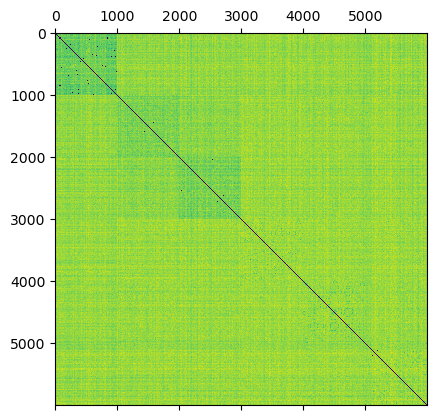

In [12]:
plt.matshow(torsion_distance)

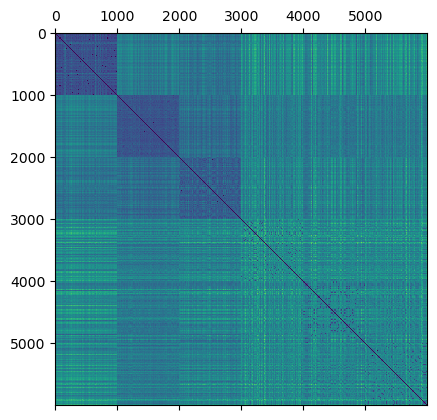

In [13]:
plt.matshow(alpha_distance)

In [1]:
#import pandas as pd

In [2]:
path = "/expanse/lustre/projects/uil133/josephdb/SimulationData/MotorRowRuns/9THC/9THC_step5_test.tsv"
#df = pd.read_csv(path, sep="\t", comment="#", engine="python", on_bad_lines="skip")

In [3]:
with open(path, 'r') as f:
    lines = [line[:-1].split('\t') if line.endswith('\n') else line.split('\t') for line in f.read().split('\n')]

In [4]:
headers, data_lines = lines[:2], lines[2:-1]

In [5]:
for line in data_lines:
    try:
        int(line[0])
    except:
        print(data_lines.index(line), line)


In [6]:
import numpy as np

frame = np.array([int(line[0]) for line in data_lines])
inter_type = np.array([str(line[1]) for line in data_lines])
atom_1 = np.array([str(line[2]) for line in data_lines])
atom_2 = np.array([str(line[3]) for line in data_lines])

n_frames, n_interactions, n_atom_1s, n_atom_2s = [np.unique(arr).shape[0] for arr in [frame, inter_type, atom_1, atom_2]]
unique_interactions = np.unique(np.stack((inter_type, atom_1, atom_2)).T, axis=0)

In [7]:
#convert data to integers for rapid processing...

In [8]:
map_unique_ints = -1*np.ones(unique_interactions.shape, dtype=np.int32)
map_inter_types = -1*np.ones(inter_type.shape, dtype=np.int32)
map_atom_1 = -1*np.ones(atom_1.shape, dtype=np.int32)
map_atom_2 = -1*np.ones(atom_2.shape, dtype=np.int32)

In [10]:
for i, inter in enumerate(np.unique(inter_type)):
    #print(i, inter)
    map_unique_ints[np.where(unique_interactions == inter)] = i
    map_inter_types[np.where(inter_type == inter)] = i

for i, nth_atom_1 in enumerate(np.unique(atom_1)):
    #print(i, nth_atom_1)
    map_unique_ints[np.where(unique_interactions == nth_atom_1)] = i
    map_atom_1[np.where(atom_1 == nth_atom_1)] = i

for i, nth_atom_2 in enumerate(np.unique(atom_2)):
    #print(i, nth_atom_2)
    map_unique_ints[np.where(unique_interactions == nth_atom_2)] = i
    map_atom_2[np.where(atom_2 == nth_atom_2)] = i

In [11]:
map_unique_ints

array([[   0,    3,  828],
       [   0,    3, 1205],
       [   0,    3, 1675],
       ...,
       [  12, 1568, 1664],
       [  12, 1616, 1738],
       [  12, 1639, 1664]], shape=(14825, 3), dtype=int32)

In [14]:
#All empty means that all were assigned to an integer
[np.where(arr == -1) for arr in [map_unique_ints, map_inter_types, map_atom_1, map_atom_2]]

[(array([], dtype=int64), array([], dtype=int64)),
 (array([], dtype=int64),),
 (array([], dtype=int64),),
 (array([], dtype=int64),)]

In [ ]:
#Assign frames
frame_assignments = np.zeros((np.unique(frame).shape[0], unique_interactions.shape[0]))

In [25]:
import jax
import jax.numpy as jnp
unique_index = lambda map_interaction: jnp.where(jnp.all(map_unique_ints == map_interaction, axis=1))

In [26]:
frame_ind = 69

result = jax.vmap(unique_index, in_axes=(0))(np.stack((map_inter_types[np.where(frame_ind == frame)],
                                          map_atom_1[np.where(frame_ind == frame)],
                                          map_atom_2[np.where(frame_ind == frame)])).T)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int32[]
The size argument of jnp.nonzero must be statically specified to use jnp.nonzero within JAX transformations.
This BatchTracer with object id 23455216808112 was created on line:
  /scratch/josephdb/job_47273280/ipykernel_619722/192326224.py:3:39 (<lambda>)

See https://docs.jax.dev/en/latest/errors.html#jax.errors.ConcretizationTypeError

In [ ]:

#N-samples,N-features

for frame_ind in np.arange(n_frames):
    if frame_ind % 100 == 0:
        print(frame_ind)
    interactions_this_frame = np.stack((inter_type[np.where(frame_ind == frame)],
                                        atom_1[np.where(frame_ind == frame)],
                                        atom_2[np.where(frame_ind == frame)])).T
    unique_indices = np.apply_along_axis(unique_index, 1, interactions_this_frame)[:, 0, 0]
    frame_assignments[frame_ind, unique_indices] += 1 

In [ ]:
print(frame_assignments)